### Imports

In [1]:
import random
import datetime

import numpy as np

import qutip as qt

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mpl_colors

from IPython.display import HTML
from matplotlib import animation

%load_ext autoreload
%autoreload 2

from utils import *

plt.rcParams["font.family"] = "serif"  # 'sans-serif', 'monospace', etc.
plt.rcParams["font.serif"] = ["Times New Roman"]  # Specific serif font
plt.rcParams["font.size"] = 14  # Global font size
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{braket}'

### System parameters

In [2]:
N_default = 80
gkp_delta = 0.3
gkp_cutoff = 10
gkp_alpha = np.sqrt(np.pi / 2)
gkp_beta = np.sqrt(np.pi/ 2) * 1j

vac = qt.basis(N_default, 0)

gkp_0, gkp_1 = generate_gkp_state(N_default, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
even_cat, odd_cat = generate_cat_state(N_default, gkp_alpha)
squeezed_state = qt.squeeze(N_default, -np.log(gkp_delta)) * vac

input_squeezing = -10 * np.log10(gkp_delta**2)
print(f"GKP: {input_squeezing}")

GKP: 10.457574905606752


### Plot Wigner distributions

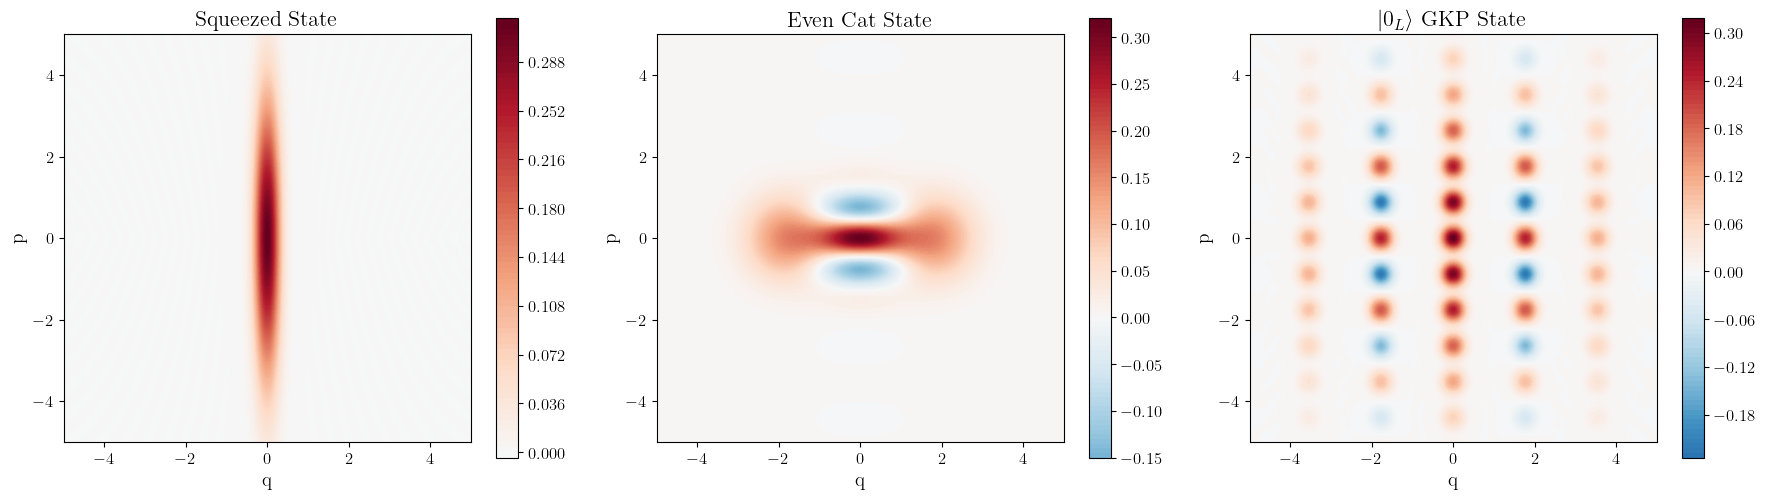

In [3]:
# Wigner functions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_wigner_function(squeezed_state, x_bound=5, y_bound=5, ax=axes[0])
plot_wigner_function(even_cat, x_bound=5, y_bound=5, ax=axes[1])
plot_wigner_function(gkp_0, x_bound=5, y_bound=5, ax=axes[2])

axes[0].set_title("Squeezed State")
axes[1].set_title("Even Cat State")
axes[2].set_title(r"$\ket{0_L}$ GKP State")

plt.tight_layout()
plt.savefig("../figs/bosonic_state_wigner_distributions.pdf", bbox_inches="tight")
plt.show()

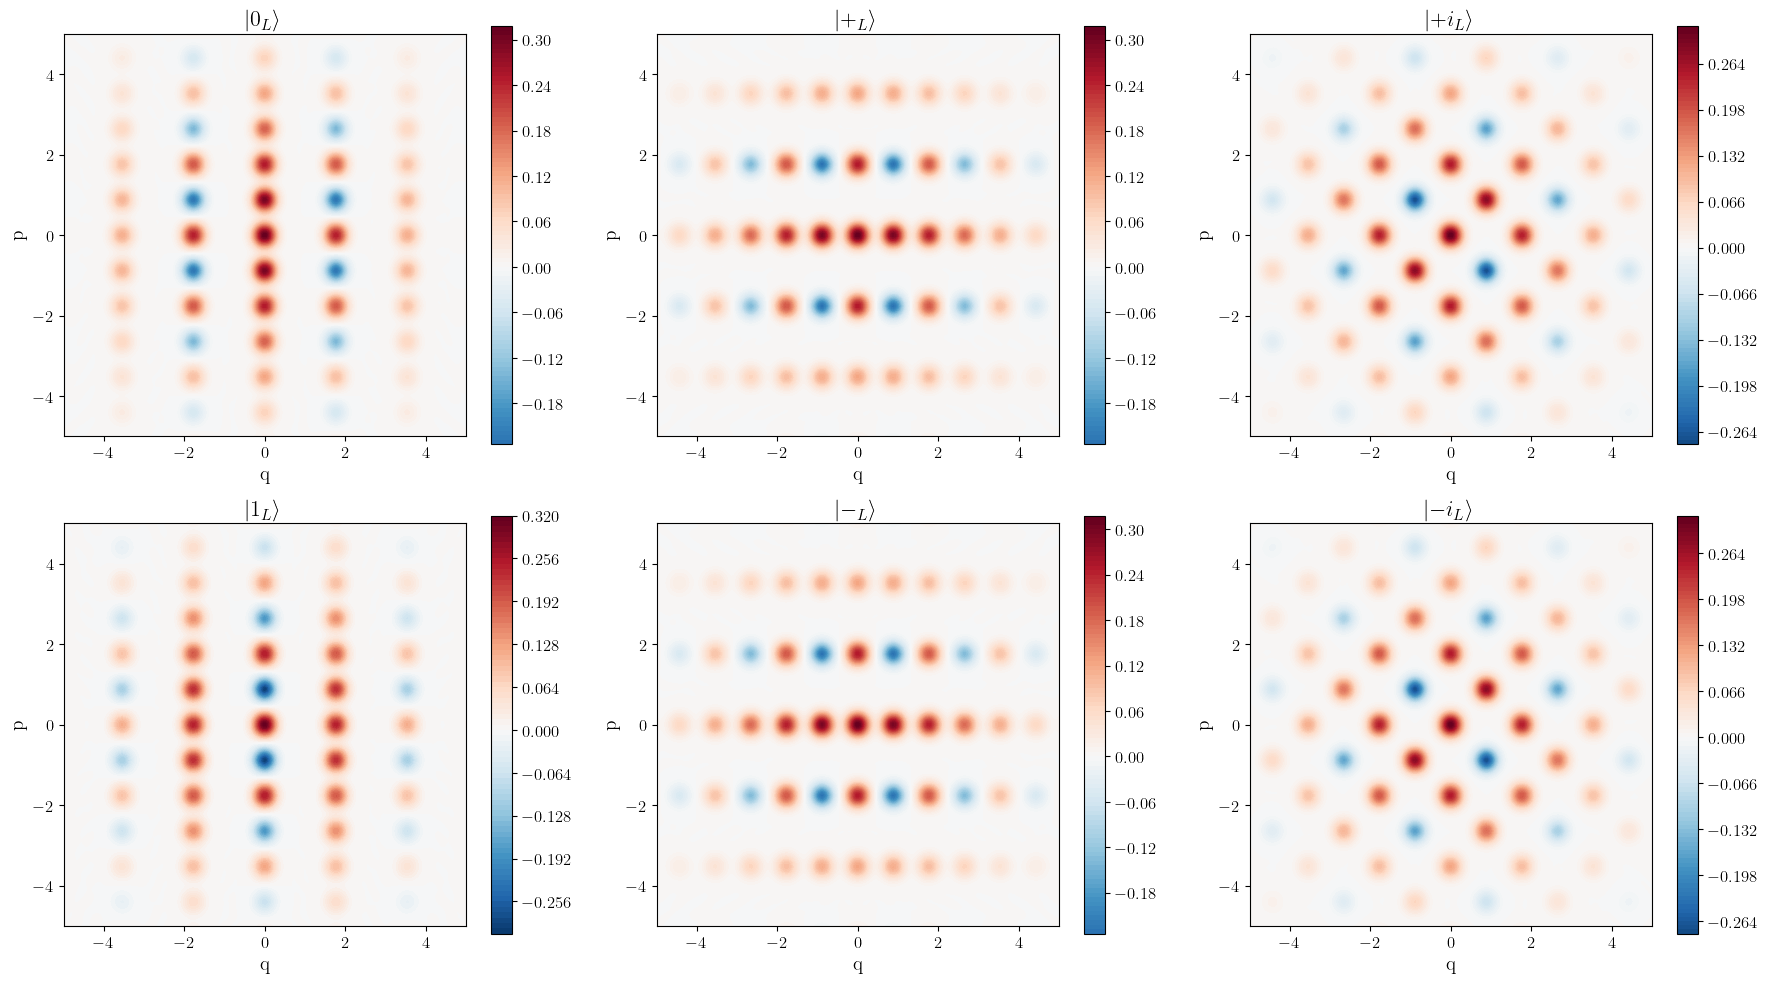

In [4]:
# Wigner functions for GKP States
gkp_x_plus = (gkp_0 + gkp_1).unit()
gkp_x_minus = (gkp_0 + gkp_1).unit()
gkp_y_plus = (gkp_0 + 1j * gkp_1).unit()
gkp_y_minus = (gkp_0 + 1j * gkp_1).unit()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_wigner_function(gkp_0, x_bound=5, y_bound=5, ax=axes[0, 0])
plot_wigner_function(gkp_1, x_bound=5, y_bound=5, ax=axes[1, 0])
plot_wigner_function(gkp_x_plus, x_bound=5, y_bound=5, ax=axes[0, 1])
plot_wigner_function(gkp_x_minus, x_bound=5, y_bound=5, ax=axes[1, 1])
plot_wigner_function(gkp_y_plus, x_bound=5, y_bound=5, ax=axes[0, 2])
plot_wigner_function(gkp_y_minus, x_bound=5, y_bound=5, ax=axes[1, 2])

axes[0, 0].set_title(r"$\ket{0_L}$")
axes[1, 0].set_title(r"$\ket{1_L}$")
axes[0, 1].set_title(r"$\ket{+_L}$")
axes[1, 1].set_title(r"$\ket{-_L}$")
axes[0, 2].set_title(r"$\ket{+i_L}$")
axes[1, 2].set_title(r"$\ket{-i_L}$")

plt.tight_layout()

plt.savefig("../figs/gkp_wigner_distributions.pdf", bbox_inches="tight")

plt.show()

### Plot Photon Distributions

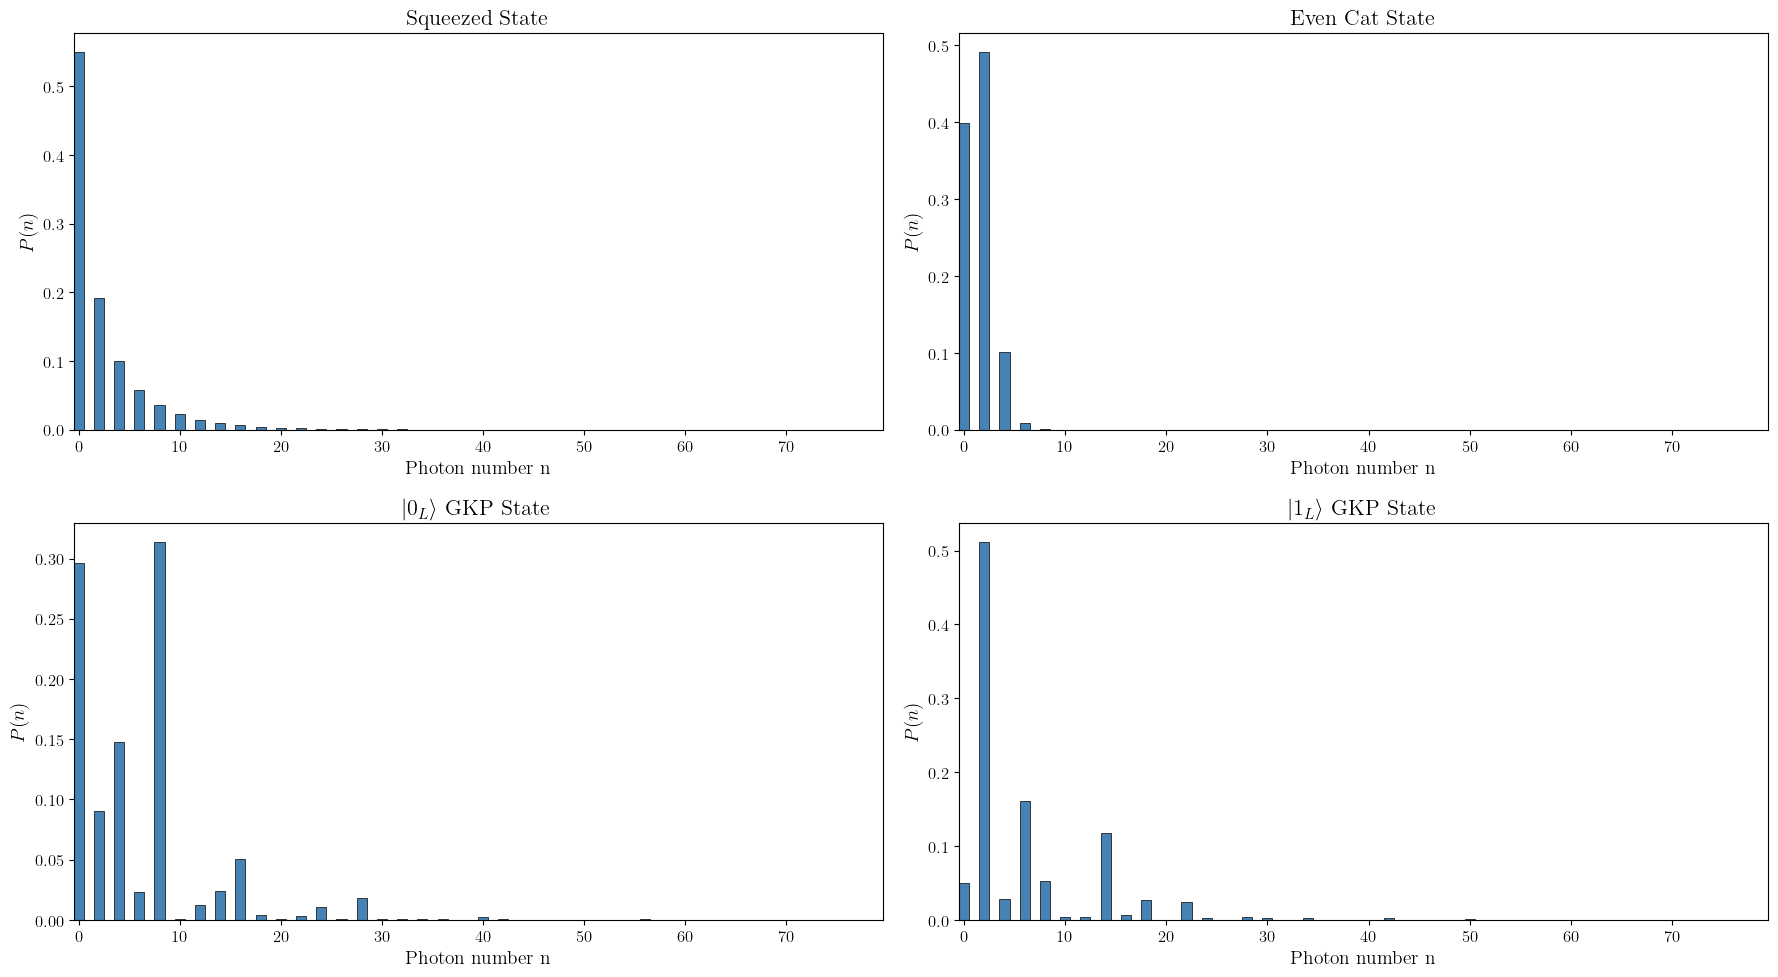

In [5]:
# Photon Distributions
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

plot_photon_distribution(squeezed_state, ax=axes[0,0])
plot_photon_distribution(even_cat, ax=axes[0,1])
plot_photon_distribution(gkp_0, ax=axes[1,0])
plot_photon_distribution(gkp_1, ax=axes[1,1])

axes[0,0].set_title("Squeezed State")
axes[0,1].set_title("Even Cat State")
axes[1,0].set_title(r"$\ket{0_L}$ GKP State")
axes[1,1].set_title(r"$\ket{1_L}$ GKP State")

plt.tight_layout()
plt.savefig("../figs/bosonic_states_photon_distributions.pdf", bbox_inches="tight")

plt.show()

### Plot different levels of GKP squeezing

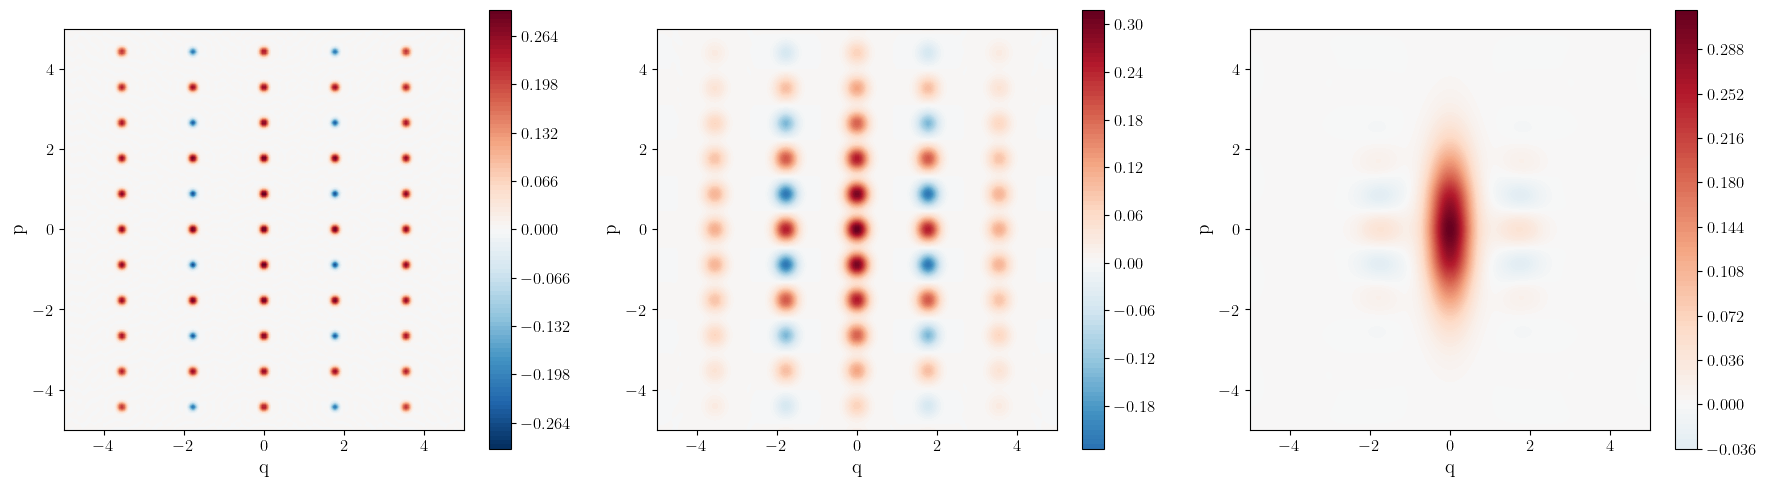

In [7]:
# Different deltas
deltas = [0.1, 0.3, 1.0]
fig, axs = plt.subplots(1, len(deltas), figsize=(18, 5))
cutoff = 10

for i, delta in enumerate(deltas):
    N = max(int(-np.log(delta) * 100), N_default)

    title = rf"$\Delta={delta}$"
    gkp_0, gkp_1 = generate_gkp_state(N, gkp_alpha, gkp_beta, delta, gkp_cutoff)
    plot_wigner_function(gkp_0, x_bound=5, y_bound=5, ax=axs[i])

plt.tight_layout()
plt.savefig("../figs/different_gkp_squeezing_wigners.pdf", bbox_inches="tight")

plt.show()